# Klasyfikacja obrazów CIFAR-10

Projekt bada różne architektury sieci neuronowych na zbiorze CIFAR-10.
Celem jest osiągnięcie dokładności powyżej 75% na zbiorze testowym.

Zbiór CIFAR-10 zawiera 60 000 kolorowych obrazów 32×32 px podzielonych na 10 klas:
samolot, samochód, ptak, kot, jeleń, pies, żaba, koń, statek, ciężarówka.

https://www.cs.toronto.edu/~kriz/cifar.html

In [1]:
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor, Normalize, Compose
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

## 1. Wczytanie i wizualizacja danych
Wczytanie zbióru CIFAR-10 i wyświetlenie przykładowych obrazów z każdej klasy.

CIFAR10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


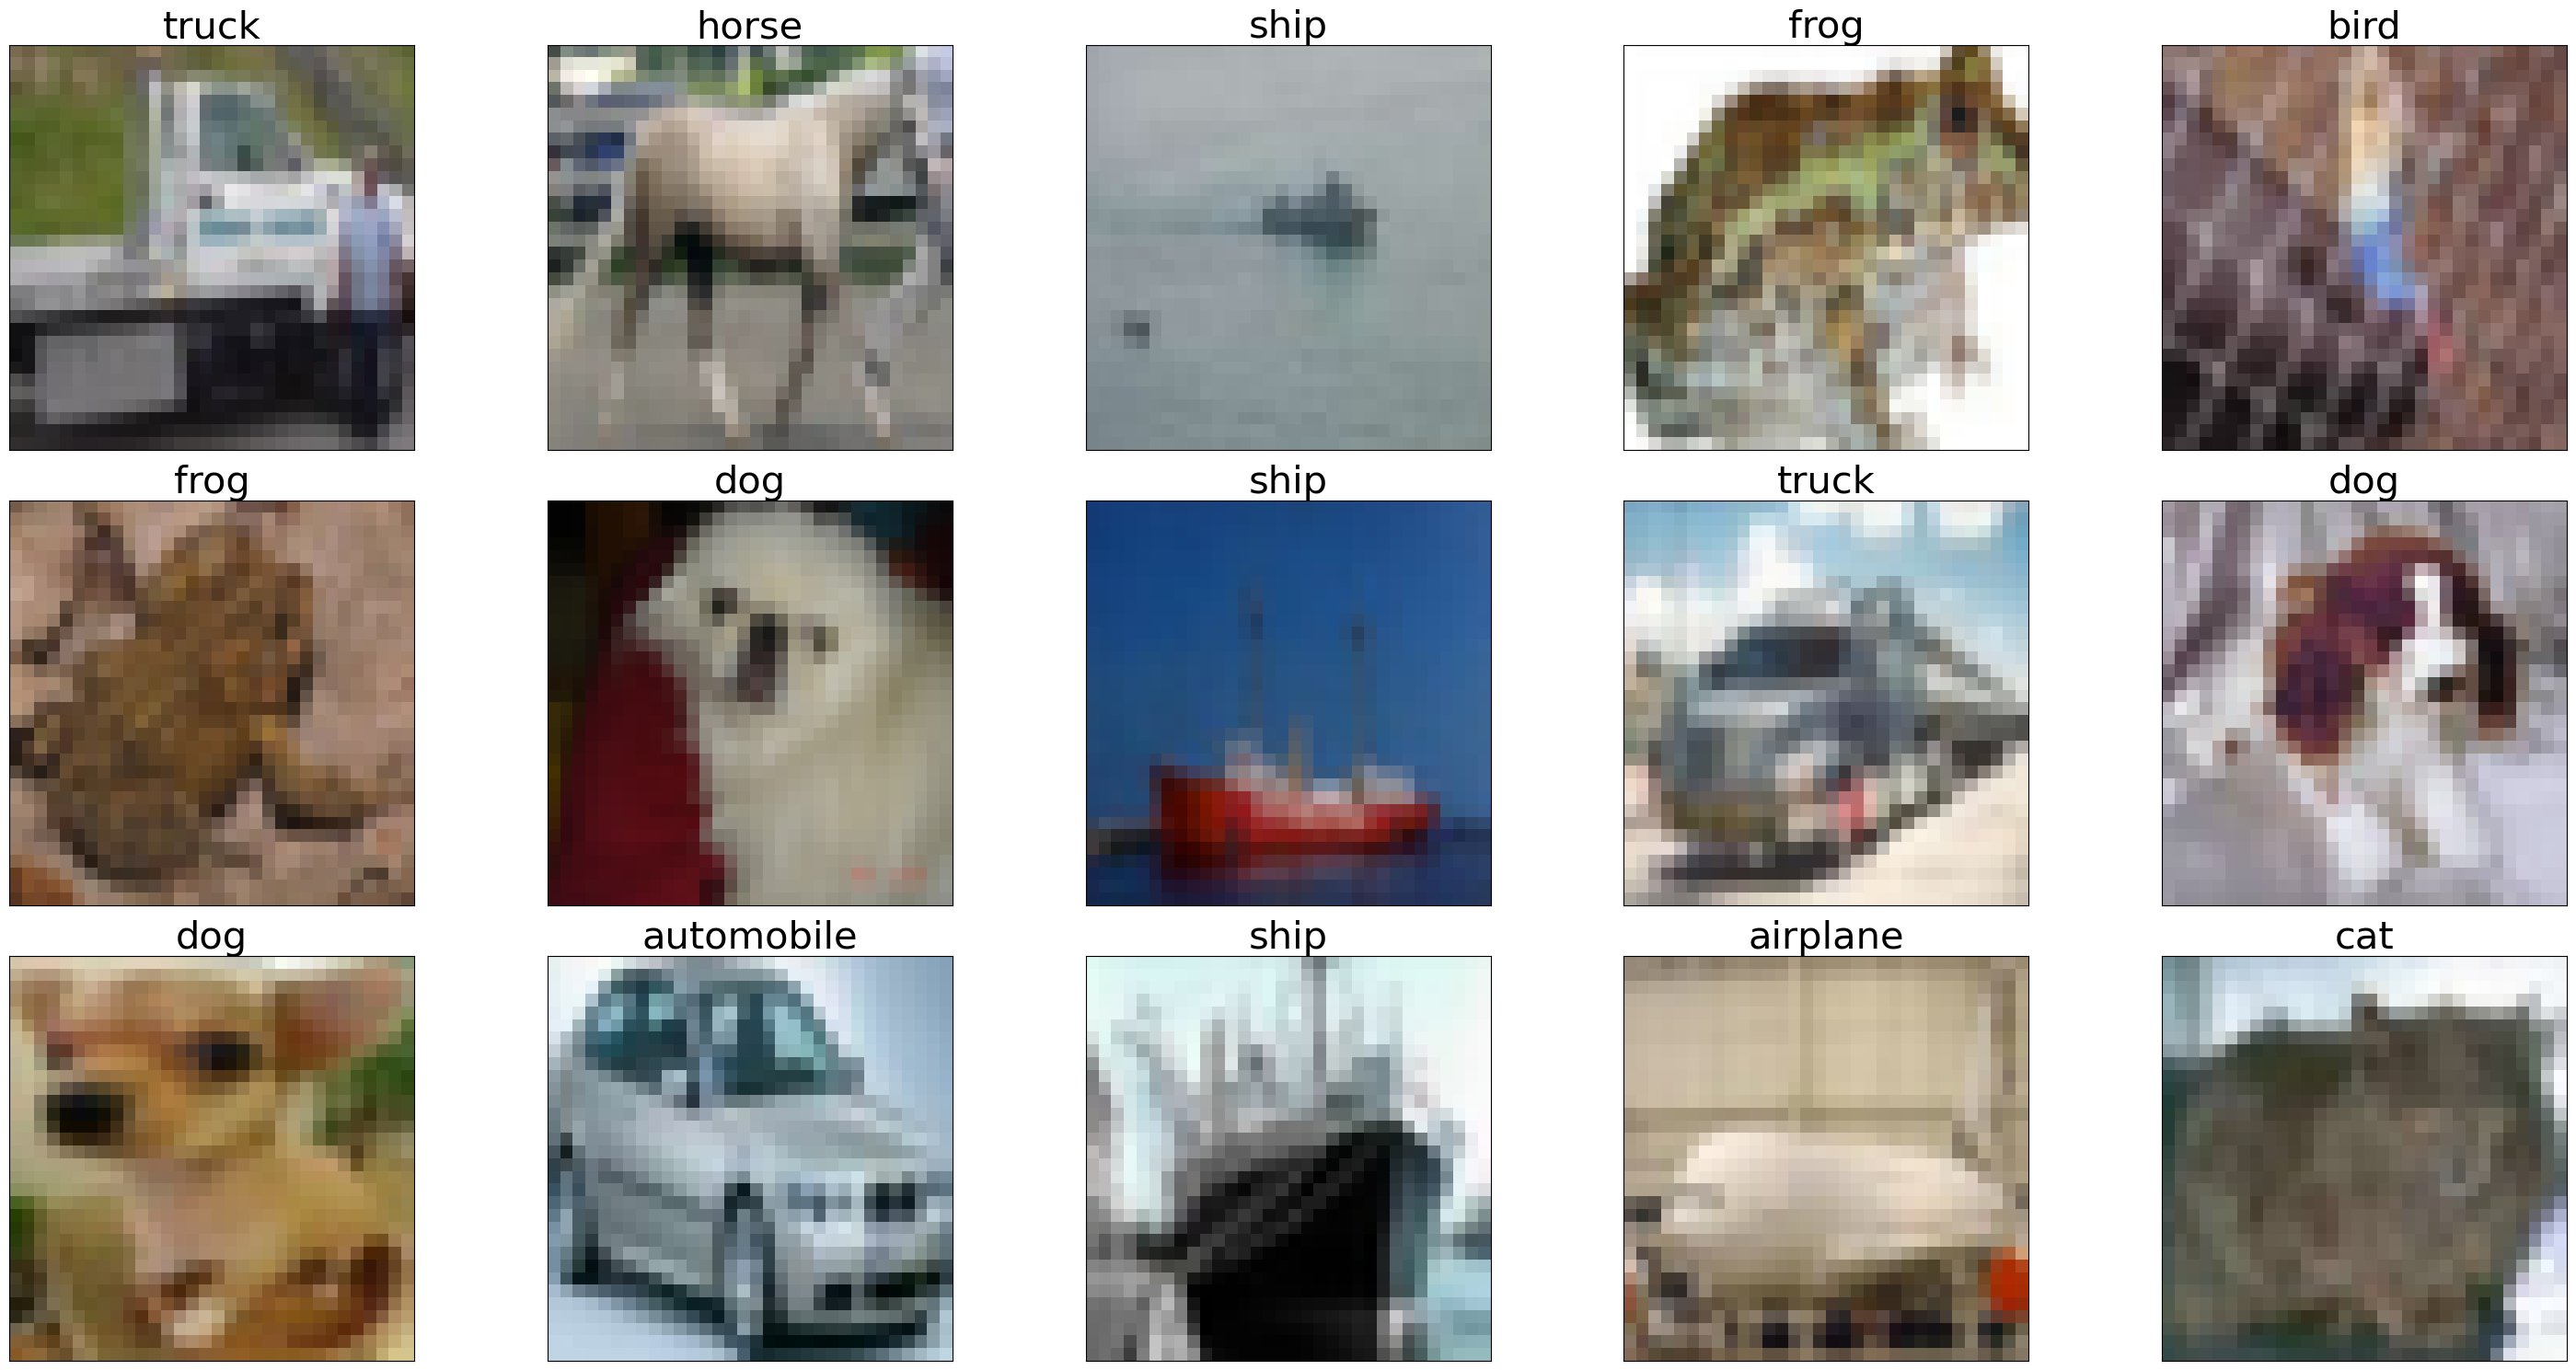

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

dataset = CIFAR10(root='.', train=True, transform=ToTensor(), download=False) #train = True <- treningowy, False- - testowy
loader = DataLoader(dataset, batch_size=15, shuffle=True)

for x, y in loader:
    break

#wizaulizacja
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(30, 15))
for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ind = 5 * i + j
        ax.imshow(np.transpose(x[ind], (1, 2, 0)))
        ax.set_title(f"{dataset.classes[y[ind]]}", fontdict={'size': 30})
        ax.set_xticks([])
        ax.set_yticks([])

fig.tight_layout()

print(f"CIFAR10 classes: {dataset.classes}")

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

In [4]:
torch.manual_seed(1)

CIFAR10_data = datasets.CIFAR10('data', train=True, download=False, transform=transforms.ToTensor())
CIFAR10_data = list(CIFAR10_data)
CIFAR10_train = CIFAR10_data[:1000]
CIFAR10_val   = CIFAR10_data[1000:51000]

In [5]:
CIFAR10_data[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [6]:
CIFAR10_data[0][0].shape

torch.Size([3, 32, 32])

In [7]:
CIFAR10_data[0][1]

6

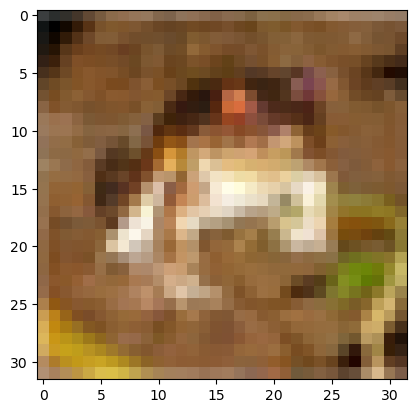

In [8]:
img = CIFAR10_data[0][0].squeeze()          #rozmiar (3, 32, 32)
img = img.permute(1, 2, 0)                  #zamiana rozmiaru na (32, 32, 3), tak aby można było wyświetlić za pomocą Matplotlib

plt.imshow(img)
plt.show()

## 2. Model bazowy — sieć w pełni połączona (FC)

Jako punkt odniesienia testowano prostą sieć składającą się z trzech warstw liniowych.
Obrazy są spłaszczane do wektora o rozmiarze 3×32×32 = 3072 wartości.

In [9]:
class CIFAR10Classifier(nn.Module):
    def __init__(self):
        super(CIFAR10Classifier, self).__init__()
        self.layer1 = nn.Linear(3 * 32 * 32, 50)
        self.layer2 = nn.Linear(50, 20)
        self.layer3 = nn.Linear(20, 10)
    def forward(self, img):
        x = img.view(-1, 3* 32 * 32)
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        
        out = self.layer3(x)
        return out

In [10]:
def get_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


def train(model, train, valid, batch_size=32, num_epochs=5, learn_rate=0.01, weight_decay=0):
    train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(valid, batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learn_rate, momentum=0.9, weight_decay=weight_decay)

    losses, train_acc, val_acc = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            #Forward
            out = model(imgs)
            loss = criterion(out, labels)
            
            #Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # średni loss z epoki
        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)

        # accuracy raz na epokę
        train_accuracy = get_accuracy(model, train_loader, device)
        val_accuracy = get_accuracy(model, val_loader, device)

        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)

        if epoch%1 == 0: #drukowanie przy każdje epoce
            print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, "
                  f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")

    # wykresy
    plt.plot(losses)
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.plot(train_acc, label="Train")
    plt.plot(val_acc, label="Validation")
    plt.legend()
    plt.title("Accuracy")
    plt.show()

In [11]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Epoch 1, Loss: 2.2940, Train Acc: 0.1930, Val Acc: 0.1806
Epoch 2, Loss: 2.2238, Train Acc: 0.2230, Val Acc: 0.2052
Epoch 3, Loss: 2.1320, Train Acc: 0.2030, Val Acc: 0.1913
Epoch 4, Loss: 2.0970, Train Acc: 0.2300, Val Acc: 0.1945
Epoch 5, Loss: 2.0093, Train Acc: 0.2950, Val Acc: 0.2511


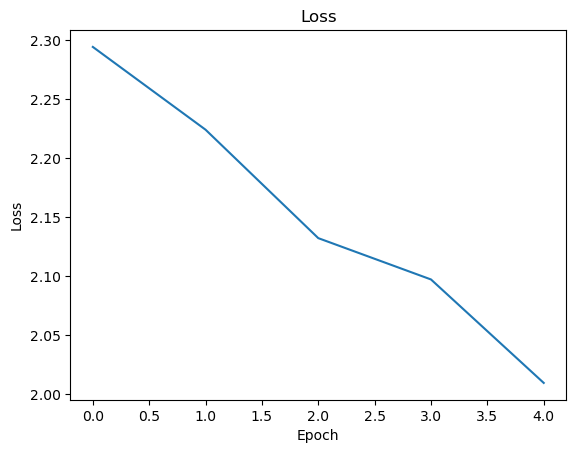

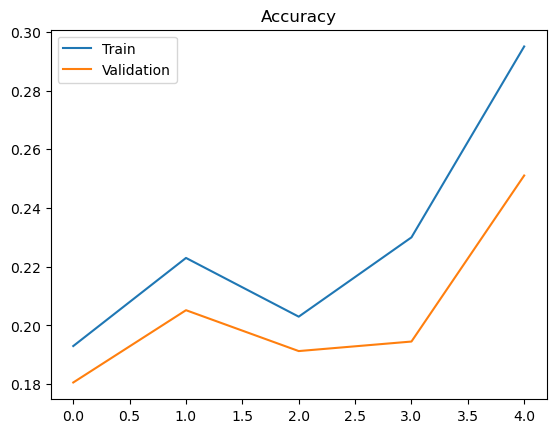

In [12]:
model = CIFAR10Classifier()
train(model, CIFAR10_train, CIFAR10_val, num_epochs=5)

## 3. Regularyzacja sieci FC
Przetestowano dwa mechanizmy regularyzacji, które mają ograniczyć przeuczenie:
- **Weight decay** — kara za duże wagi (regularyzacja L2)
- **Dropout** — losowe wyłączanie neuronów podczas trenowania

Epoch 1, Loss: 2.3048, Train Acc: 0.0900, Val Acc: 0.0970
Epoch 2, Loss: 2.2977, Train Acc: 0.1830, Val Acc: 0.1653
Epoch 3, Loss: 2.2494, Train Acc: 0.2030, Val Acc: 0.1976
Epoch 4, Loss: 2.1579, Train Acc: 0.2190, Val Acc: 0.2098
Epoch 5, Loss: 2.0518, Train Acc: 0.2190, Val Acc: 0.2089


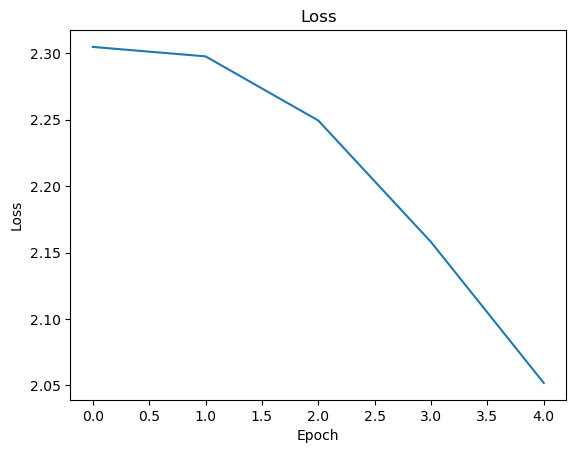

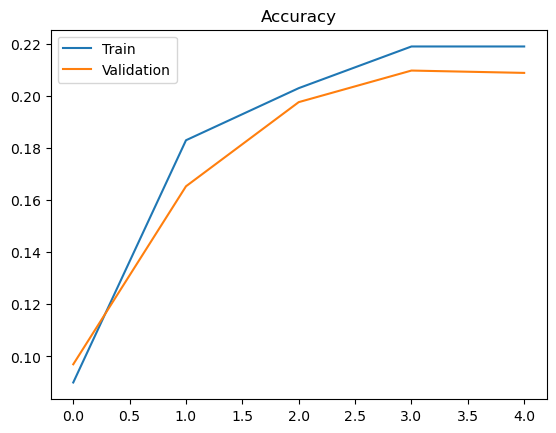

In [13]:
#weight-decay
model = CIFAR10Classifier()
train(model, CIFAR10_train, CIFAR10_val, num_epochs=5, weight_decay=0.001)

Epoch 1, Loss: 2.3003, Train Acc: 0.1240, Val Acc: 0.1039
Epoch 2, Loss: 2.2565, Train Acc: 0.1430, Val Acc: 0.1471
Epoch 3, Loss: 2.2080, Train Acc: 0.2000, Val Acc: 0.1897
Epoch 4, Loss: 2.1713, Train Acc: 0.2220, Val Acc: 0.2090
Epoch 5, Loss: 2.1367, Train Acc: 0.2560, Val Acc: 0.2235


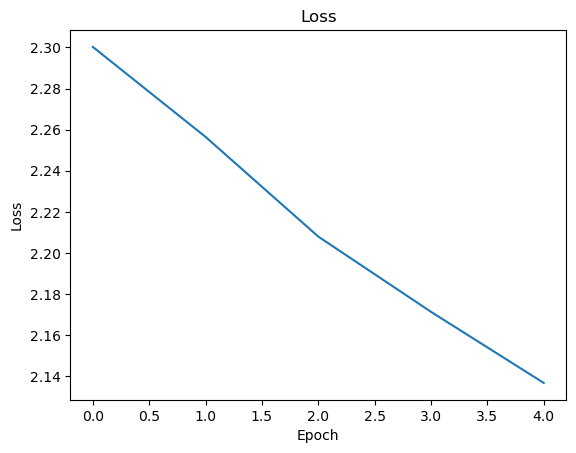

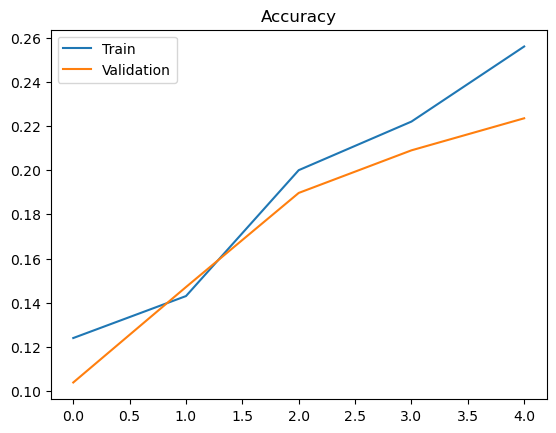

In [14]:
#dropout
class CIFAR10ClassifierWithDropout(nn.Module):
    def __init__(self):
        super(CIFAR10ClassifierWithDropout, self).__init__()
        self.layer1 = nn.Linear(3 * 32 * 32, 50)
        self.layer2 = nn.Linear(50, 20)
        self.layer3 = nn.Linear(20, 10)
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.2)

    def forward(self, img):
        x = img.view(-1, 3 * 32 * 32)
        x = F.relu(self.layer1(x))
        x = self.dropout1(x)
        x = F.relu(self.layer2(x))
        x = self.dropout2(x)
        x = self.layer3(x)
        return x


model = CIFAR10ClassifierWithDropout()
train(model, CIFAR10_train, CIFAR10_val, num_epochs=5)

## 4. Sieć konwolucyjna (CNN)

Sprawdzanie sieci konwolucyjnych, które lepiej radzą sobie z obrazami —
warstwy konwolucyjne wykrywają lokalne cechy (krawędzie, tekstury) zamiast
przetwarzać każdy piksel osobno.

Pierwsza wersja składa się z dwóch bloków konwolucyjnych z normalizacją (BatchNorm).

In [15]:
#Wykorzystanie CNN (konwolucyjnych sieci neuronowych)
train_dataset = datasets.CIFAR10('data', train=True, download=False, transform=transforms.ToTensor()) 
test_dataset = datasets.CIFAR10('data', train=False, download=False, transform=transforms.ToTensor()) 

In [16]:
len(train_dataset), len(test_dataset)

(50000, 10000)

In [17]:
train_dataset[0][0].shape

torch.Size([3, 32, 32])

In [18]:
train_dataset[0][1]

6

In [19]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [20]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=100, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100, shuffle=False)

In [21]:
def get_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [22]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

#Parametry do trenowania 
num_epochs = 3
num_classes = 10 
learning_rate = 0.001


#Sieć konwolucyjna
class ConvNet(nn.Module):
    def __init__(self, num_classes):
        super(ConvNet, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.fc = nn.Linear(8*8*32, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out


#model
model = ConvNet(num_classes).to(device)

#funkcja kosztu i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [23]:
def training_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    losses = []
    train_acc = []
    val_acc = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
    
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
    
            #Forward
            outputs = model(images)
            loss = criterion(outputs, labels)
    
            #Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item()
    
        #średnia strata z epoki
        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)
    
        #dokładność
        train_accuracy = get_accuracy(model, train_loader)
        val_accuracy = get_accuracy(model, val_loader)
    
        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)
    
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, "
              f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")
    
    #Funkcja kosztu
    plt.plot(losses)
    plt.title("Loss per epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()
    
    #Dokładność
    plt.plot(train_acc, label="Train")
    plt.plot(val_acc, label="Validation")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    return losses, train_acc, val_acc

Epoch 1/3, Loss: 1.4102, Train Acc: 0.5396, Val Acc: 0.5218
Epoch 2/3, Loss: 1.0811, Train Acc: 0.6180, Val Acc: 0.5931
Epoch 3/3, Loss: 0.9616, Train Acc: 0.6511, Val Acc: 0.6099


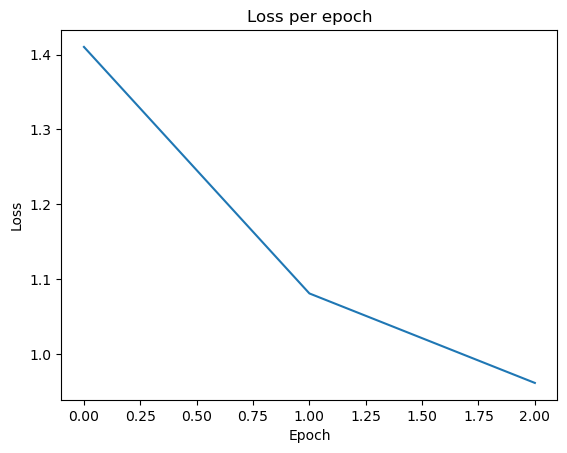

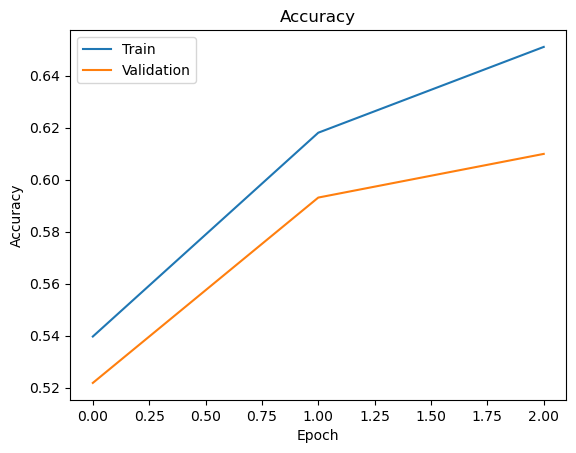

In [24]:
history_losses, history_train_acc, history_val_acc = training_model(model=model, train_loader=train_loader, val_loader=val_loader, 
                                                                    criterion=criterion, optimizer=optimizer, num_epochs=num_epochs, device=device)

In [25]:
test_accuracy = get_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6211


## 5. Eksperymenty z architekturą CNN

Testuje różne modyfikacje:
- dodanie trzeciej warstwy konwolucyjnej
- zmiana funkcji aktywacji (ReLU → LeakyReLU, Tanh)
- dropout między warstwami konwolucyjnymi
- zwiększenie liczby filtrów

In [26]:
#modyfikacja modelu sieci konwolucyjnej

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
num_epochs = 5
num_classes = 10 
learning_rate = 0.001

class ConvNet_v2(nn.Module):
    def __init__(self, num_classes):
        super(ConvNet_v2, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        #dodanie kolejnej warstwy
        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ) 

        #rozbudowananie klasyfikacyji
        self.classifier = nn.Sequential(
        nn.Linear(64 * 4 * 4, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes)
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.reshape(out.size(0), -1)
        out = self.classifier(out)
        return out

model = ConvNet_v2(num_classes).to(device)

#funkcja kosztu i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Epoch 1/5, Loss: 1.4976, Train Acc: 0.5540, Val Acc: 0.5398
Epoch 2/5, Loss: 1.1507, Train Acc: 0.5521, Val Acc: 0.5256
Epoch 3/5, Loss: 1.0140, Train Acc: 0.6917, Val Acc: 0.6617
Epoch 4/5, Loss: 0.9278, Train Acc: 0.6207, Val Acc: 0.5994
Epoch 5/5, Loss: 0.8606, Train Acc: 0.7444, Val Acc: 0.6944


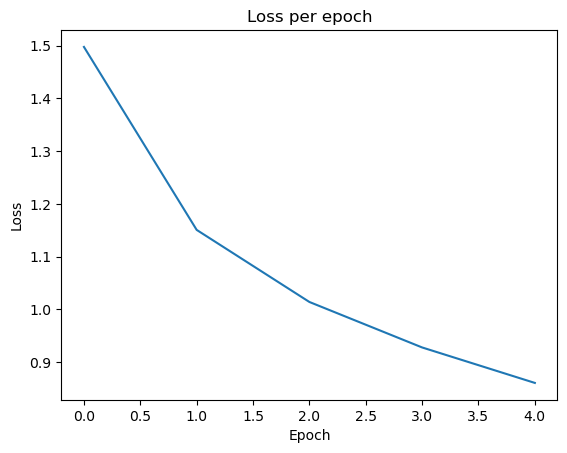

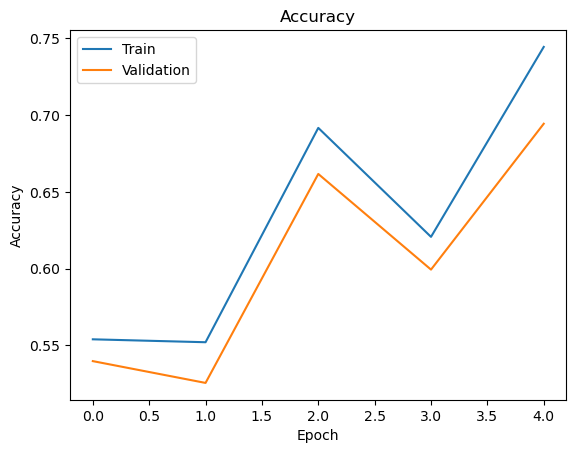

In [27]:
history_losses, history_train_acc, history_val_acc = training_model(model=model, train_loader=train_loader, val_loader=val_loader, 
                                                                    criterion=criterion, optimizer=optimizer, num_epochs=num_epochs, device=device)

In [28]:
test_accuracy = get_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7012


In [29]:
#Kolejna sieć konwolucyjna ale z inną topologią

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
num_epochs = 5
num_classes = 10 
learning_rate = 0.001

class ConvNet_v3(nn.Module):
    def __init__(self, num_classes):
        super(ConvNet_v3, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.Tanh(), #zmiania na tanh
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(), #zmiana na LeakyReLU
            nn.MaxPool2d(kernel_size=2, stride=2)
        ) 

        #klasyfikacja
        self.classifier = nn.Sequential(
        nn.Linear(64 * 4 * 4, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes)
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.reshape(out.size(0), -1)
        out = self.classifier(out)
        return out

model = ConvNet_v3(num_classes).to(device)

# funkcja kosztu i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Epoch 1/5, Loss: 1.5164, Train Acc: 0.5120, Val Acc: 0.5006
Epoch 2/5, Loss: 1.1938, Train Acc: 0.4157, Val Acc: 0.4161
Epoch 3/5, Loss: 1.0574, Train Acc: 0.6890, Val Acc: 0.6512
Epoch 4/5, Loss: 0.9653, Train Acc: 0.6471, Val Acc: 0.6203
Epoch 5/5, Loss: 0.9005, Train Acc: 0.6612, Val Acc: 0.6176


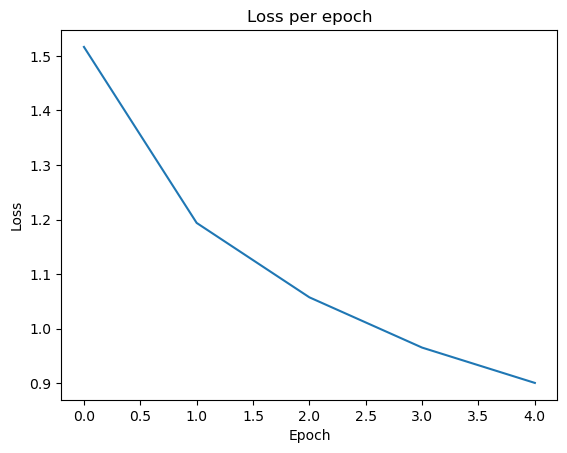

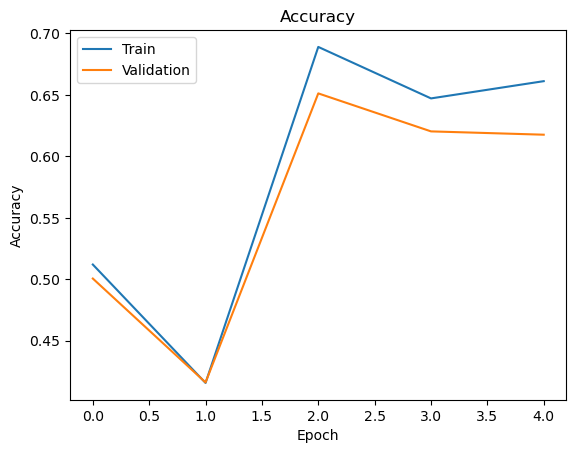

In [30]:
history_losses, history_train_acc, history_val_acc = training_model(model=model, train_loader=train_loader, val_loader=val_loader, 
                                                                    criterion=criterion, optimizer=optimizer, num_epochs=num_epochs, device=device)

In [31]:
test_accuracy = get_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6266


In [32]:
#Kolejna siec konwolucyjna

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
num_epochs = 5
num_classes = 10 
learning_rate = 0.001

class ConvNet_v4(nn.Module):
    def __init__(self, num_classes):
        super(ConvNet_v4, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        #modyfikacja częsci z regularyzacją
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.2)

        self.fc = nn.Linear(8*8*32, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.dropout1(out)
        out = self.layer2(out)
        out = self.dropout2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

model = ConvNet_v4(num_classes).to(device)

# funkcja kosztu i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay = 0.001) #dodanie weight_decay

Epoch 1/5, Loss: 1.5397, Train Acc: 0.4490, Val Acc: 0.4435
Epoch 2/5, Loss: 1.2179, Train Acc: 0.5881, Val Acc: 0.5701
Epoch 3/5, Loss: 1.0998, Train Acc: 0.6469, Val Acc: 0.6211
Epoch 4/5, Loss: 1.0424, Train Acc: 0.6686, Val Acc: 0.6379
Epoch 5/5, Loss: 0.9898, Train Acc: 0.6798, Val Acc: 0.6475


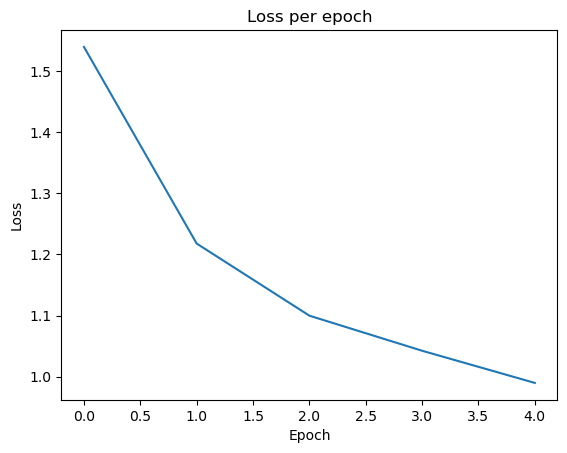

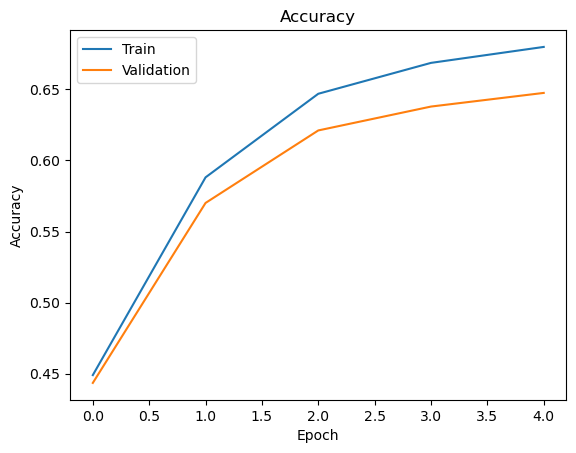

In [33]:
history_losses, history_train_acc, history_val_acc = training_model(model=model, train_loader=train_loader, val_loader=val_loader, 
                                                                    criterion=criterion, optimizer=optimizer, num_epochs=num_epochs, device=device)

In [34]:
test_accuracy = get_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6515


In [35]:
#Kolejna sieć konwolucyjna (zamiast ReLU LeakyReLU)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
num_epochs = 5
num_classes = 10 
learning_rate = 0.001

class ConvNet_v5(nn.Module):
    def __init__(self, num_classes):
        super(ConvNet_v5, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.2)

        self.fc = nn.Sequential(
            nn.Linear(8*8*64, 256),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.dropout1(out)
        out = self.layer2(out)
        out = self.dropout2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

model = ConvNet_v5(num_classes).to(device)

# funkcja kosztu i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay = 0.001)

Epoch 1/5, Loss: 1.5554, Train Acc: 0.5497, Val Acc: 0.5357
Epoch 2/5, Loss: 1.2014, Train Acc: 0.6105, Val Acc: 0.5911
Epoch 3/5, Loss: 1.0579, Train Acc: 0.6122, Val Acc: 0.5911
Epoch 4/5, Loss: 0.9899, Train Acc: 0.6747, Val Acc: 0.6483
Epoch 5/5, Loss: 0.9301, Train Acc: 0.7204, Val Acc: 0.6852


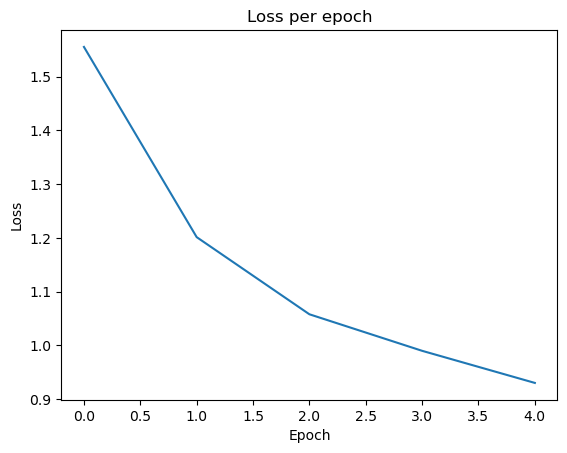

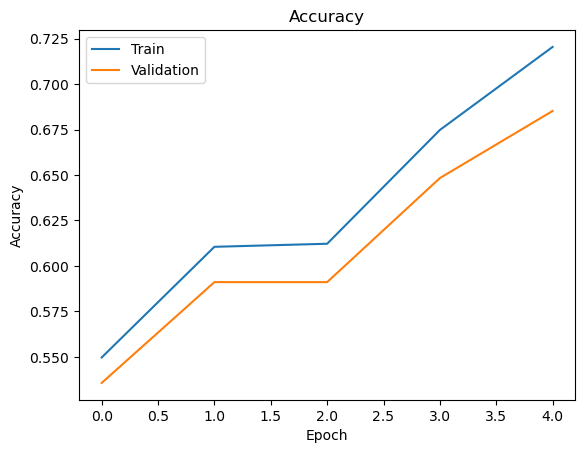

In [36]:
history_losses, history_train_acc, history_val_acc = training_model(model=model, train_loader=train_loader, val_loader=val_loader, 
                                                                    criterion=criterion, optimizer=optimizer, num_epochs=num_epochs, device=device)

In [37]:
test_accuracy = get_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6846


## 6. Finalny model

Na podstawie wcześniejszych eksperymentów wybrano najlepszą architekturę
i trenowano ją przez 20 epok. Model składa się z trzech bloków konwolucyjnych
ze wzrastającą liczbą filtrów (32→64→128) oraz rozbudowanego klasyfikatora z dropoutem.

In [38]:
#Sieć konwolucyjna (2) kóra uzyskała najwyższą dokłądność po 5 epokach (ponad 70 procent) ale z zwiększoną liczbą filtrów

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
num_epochs = 20
num_classes = 10 
learning_rate = 0.001

class ConvNet_v2(nn.Module):
    def __init__(self, num_classes):
        super(ConvNet_v2, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.reshape(out.size(0), -1)
        out = self.classifier(out)
        return out
        
model = ConvNet_v2(num_classes).to(device)

# funkcja kosztu i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay = 0.0001)

Epoch 1/20, Loss: 1.5135, Train Acc: 0.4406, Val Acc: 0.4325
Epoch 2/20, Loss: 1.1642, Train Acc: 0.6285, Val Acc: 0.6079
Epoch 3/20, Loss: 1.0094, Train Acc: 0.6690, Val Acc: 0.6391
Epoch 4/20, Loss: 0.9028, Train Acc: 0.6623, Val Acc: 0.6233
Epoch 5/20, Loss: 0.8275, Train Acc: 0.7551, Val Acc: 0.7029
Epoch 6/20, Loss: 0.7599, Train Acc: 0.7247, Val Acc: 0.6730
Epoch 7/20, Loss: 0.7091, Train Acc: 0.7156, Val Acc: 0.6665
Epoch 8/20, Loss: 0.6558, Train Acc: 0.7610, Val Acc: 0.6974
Epoch 9/20, Loss: 0.6124, Train Acc: 0.8113, Val Acc: 0.7322
Epoch 10/20, Loss: 0.5714, Train Acc: 0.7679, Val Acc: 0.6982
Epoch 11/20, Loss: 0.5291, Train Acc: 0.8122, Val Acc: 0.7221
Epoch 12/20, Loss: 0.4962, Train Acc: 0.8652, Val Acc: 0.7493
Epoch 13/20, Loss: 0.4629, Train Acc: 0.8841, Val Acc: 0.7630
Epoch 14/20, Loss: 0.4243, Train Acc: 0.8293, Val Acc: 0.7271
Epoch 15/20, Loss: 0.3934, Train Acc: 0.8394, Val Acc: 0.7141
Epoch 16/20, Loss: 0.3712, Train Acc: 0.8525, Val Acc: 0.7245
Epoch 17/20, Loss

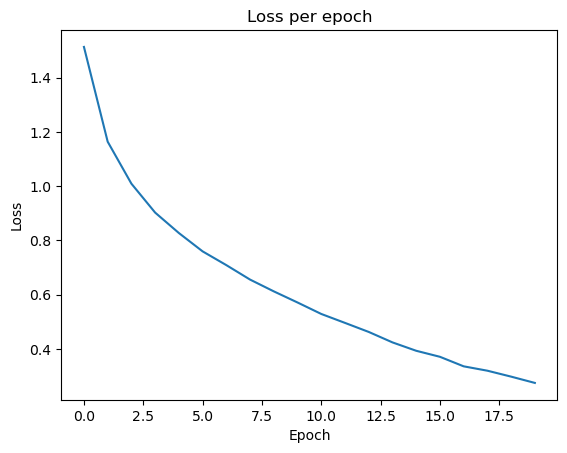

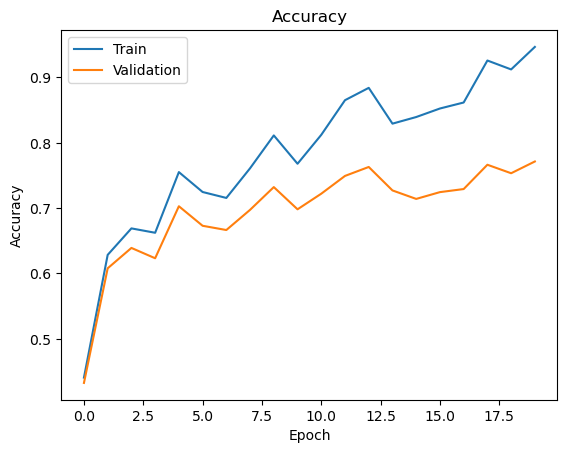

In [39]:
history_losses, history_train_acc, history_val_acc = training_model(model=model, train_loader=train_loader, val_loader=val_loader, 
                                                                    criterion=criterion, optimizer=optimizer, num_epochs=num_epochs, device=device)

In [40]:
test_accuracy = get_accuracy(model, test_loader)

print(f"Test Accuracy: {test_accuracy:.4f}") 

Test Accuracy: 0.7763


## 7. Podsumowanie

| Model | Architektura | Regularyzacja | Dokładność testowa |
|-------|-------------|---------------|--------------------|
| Baseline FC* | 3× Linear | — | ~25% |
| ConvNet v1 | 2× Conv + FC | BatchNorm | 62.1% |
| ConvNet v2 | 3× Conv + klasyfikator | Dropout 0.5 | 70.1% |
| ConvNet v3 | 3× Conv, Tanh/LeakyReLU | Dropout 0.5 | 62.7% |
| ConvNet v4 | 2× Conv + Dropout | Weight Decay | 65.2% |
| ConvNet v5 | 2× Conv, LeakyReLU | Dropout + Weight Decay | 68.5% |
| **ConvNet v2 finalny** | 3× Conv + klasyfikator | Dropout 0.5, Weight Decay | **77.6%** |

*Model FC trenowany na 1000 próbkach (walidacja), bez ewaluacji na zbiorze testowym

**Wnioski:**
- Sieci w pełni połączone osiągają ok. 25% — niewystarczające dla danych przestrzennych
- Normalizacja (BatchNorm) powoduje stabilizację procesu uczenia
- 3 bloki konwolucyjne ze wzrastającą liczbą filtrów przewyższają płytsze sieci
- Dropout (p=0.5) w klasyfikatorze skutecznie ogranicza przeuczenie